# Revisão de código 

Olá! 

Meu nome é Suelen. Estou feliz em revisar seu projeto hoje!

Quando vejo um erro pela primeira vez, apenas aponto. Deixarei você encontrá-lo e corrigi-lo sozinho. Além disso, ao longo do texto, farei algumas observações sobre melhorias no código e também farei comentários sobre suas percepções sobre o assunto. Mas se você ainda não consegue lidar com essa tarefa, darei uma dica mais precisa na próxima iteração e também alguns exemplos práticos. Estarei aberta a feedbacks e discussões sobre o tema.

Você pode encontrar meus comentários em caixas verdes, amarelas ou vermelhas como estas:


<div class="alert alert-block alert-success">
<b>Comentário: </b> <a class="tocSkip"></a>

Sucesso. Tudo está correto.
</div>

<div class="alert alert-block alert-warning">
<b>Comentário: </b> <a class="tocSkip"></a>

Observações. Algumas recomendações.
</div>

<div class="alert alert-block alert-danger">

<b>Comentário: </b> <a class="tocSkip"></a>

O bloco requer algumas correções. O trabalho não pode ser aceito com os comentários vermelhos.
</div>

Você pode me responder usando isto:

<div class="alert alert-block alert-info">
<b>Resposta do aluno</b> <a class="tocSkip"></a>
</div>



<div class="alert alert-block alert-success">
<b>Comentário: </b> <a class="tocSkip"></a>
     
Parabéns pelo projeto, Pedro! 🎉 Seu trabalho apresenta uma excelente qualidade!
Seu projeto está aprovado! Adicionei apenas algumas sugestões de melhoria opcionais.

Até a próxima!
</div>

## Passo 1. Carregue os dados e prepare-os para a análise ##

<span style="color: blue; font-family: Arial; font-size: 20px;">
Carregue os dados sobre restaurantes em LA. Certifique-se de que os tipos de dados para cada coluna estão corretos e não há valores ausentes ou duplicados. Processe-os, se necessário.

In [3]:
# Carregando todas as bibliotecas
from scipy import stats as st
import numpy as np
import scipy.stats as stats
import pandas as pd
from math import factorial
from plotly import graph_objects as go
import math
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [4]:
# Carregando o dataframe Datasets
rest_data = pd.read_csv(r'/datasets/rest_data_us_upd.csv')
rest_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9651 entries, 0 to 9650
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           9651 non-null   int64 
 1   object_name  9651 non-null   object
 2   address      9651 non-null   object
 3   chain        9648 non-null   object
 4   object_type  9651 non-null   object
 5   number       9651 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 452.5+ KB


In [5]:
# Verificando e tratando valores duplicados
print(rest_data.duplicated().sum())

0


In [6]:
# Verificando e tratando valores ausentes
print(rest_data.isna().sum())

id             0
object_name    0
address        0
chain          3
object_type    0
number         0
dtype: int64


In [7]:
rest_data['chain'].unique()

array([False, True, nan], dtype=object)

<span style="color: black; font-family: Arial; font-size: 20px;">
Como os valores ausentes da coluna 'chain' já estão como Nan, não há necessidade de tratar esses valores.

<div class="alert alert-block alert-success">
<b>Comentário: </b> <a class="tocSkip"></a>

- Dados foram processados corretamente.
- Adicionados comentários relevantes para análise

</div>

## Passo 2. Análise de dados ##

<span style="color: blue; font-family: Arial; font-size: 20px;">
Investigue as proporções de vários tipos de estabelecimentos. Construa um gráfico.

In [8]:
rest_data.head()

,id,object_name,address,chain,object_type,number
0,11786,HABITAT COFFEE SHOP,3708 N EAGLE ROCK BLVD,False,Cafe,26
1,11787,REILLY'S,100 WORLD WAY 120,False,Restaurant,9
2,11788,STREET CHURROS,6801 HOLLYWOOD BLVD 253,False,Fast Food,20
3,11789,TRINITI ECHO PARK,1814 W SUNSET BLVD,False,Restaurant,22
4,11790,POLLEN,2100 ECHO PARK AVE,False,Restaurant,20


In [9]:
# Verificando os tipos de estabelecimentos
rest_data['object_type'].unique()

array(['Cafe', 'Restaurant', 'Fast Food', 'Bakery', 'Bar', 'Pizza'],
      dtype=object)

In [10]:
# Contando estabelecimentos por tipo
counts_by_type = rest_data['object_type'].value_counts().reset_index()
counts_by_type.columns = ['object_type', 'count']
counts_by_type

,object_type,count
0,Restaurant,7255
1,Fast Food,1066
2,Cafe,435
3,Pizza,320
4,Bar,292
5,Bakery,283


In [11]:
# Calculando o total de estabelecimentos
total_establishments = counts_by_type['count'].sum()
total_establishments

9651

In [12]:
# Adicionando a proporção
counts_by_type['proportion'] = counts_by_type['count'] / total_establishments
counts_by_type = counts_by_type.sort_values(by='proportion', ascending=False)
counts_by_type

,object_type,count,proportion
0,Restaurant,7255,0.751736
1,Fast Food,1066,0.110455
2,Cafe,435,0.045073
3,Pizza,320,0.033157
4,Bar,292,0.030256
5,Bakery,283,0.029323


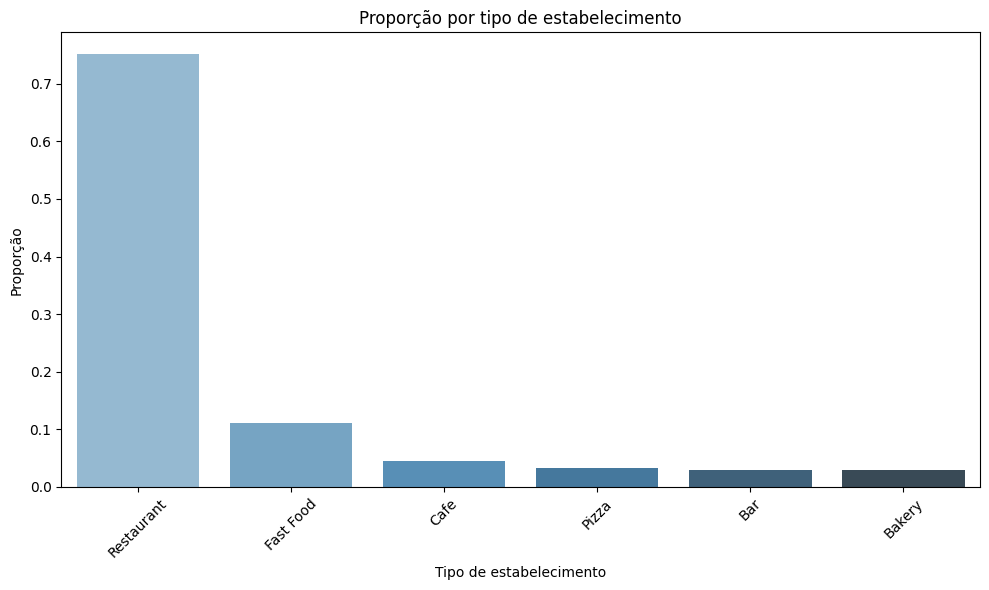

In [62]:
# Plotando o gráfico
plt.figure(figsize=(10, 6))
sns.barplot(data=counts_by_type, x='object_type', y='proportion', palette='Blues_d')

plt.title('Proporção por tipo de estabelecimento')
plt.xlabel('Tipo de estabelecimento')
plt.ylabel('Proporção')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<span style="color: black; font-family: Arial; font-size: 20px;">
“Restaurant” representa mais de 70% de todos os estabelecimentos.

<span style="color: blue; font-family: Arial; font-size: 20px;">
Investigue as proporções de estabelecimentos de rede e não. Construa um gráfico.

In [14]:
# Contando esbelecimentos de rede e sem rede.
chain_counts = rest_data['chain'].value_counts().reset_index()
chain_counts.columns = ['chain', 'count']
chain_counts

,chain,count
0,False,5972
1,True,3676


In [15]:
# Calculando o total de esbelecimentos de rede e sem rede.
total_chain = chain_counts['count'].sum()
total_chain

9648

In [16]:
# Calculando a proporção
total_chain = chain_counts['count'].sum()
chain_counts['proportion'] = chain_counts['count'] / total_chain
chain_counts

,chain,count,proportion
0,False,5972,0.618988
1,True,3676,0.381012


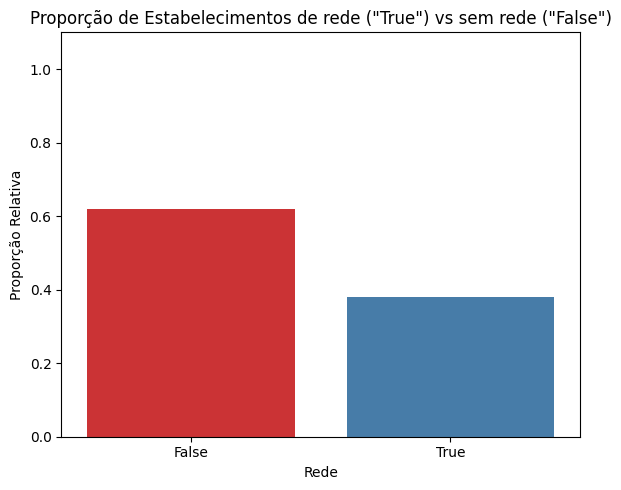

In [17]:
plt.figure(figsize=(6, 5))
sns.barplot(data=chain_counts, x='chain', y='proportion', palette='Set1')
plt.title('Proporção de Estabelecimentos de rede ("True") vs sem rede ("False")')
plt.xlabel('Rede')
plt.ylabel('Proporção Relativa')
plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-warning">
<b>Comentário: </b> <a class="tocSkip"></a>

O grafico está correto! Caso queira aprimorar ainda mais, recomendo a nomeação automatica de estabelecimentos de rede e não rede

```python
# Contar proporção de rede vs não-rede
chain_counts = data['chain'].value_counts(normalize=True)
plt.figure(figsize=(6,4))
sns.barplot(x=chain_counts.index.map({True: 'Rede', False: 'Não-Rede'}), y=chain_counts.values)

plt.title('Proporção de Estabelecimentos de Rede vs Não-Rede')
plt.ylabel('Proporção')
plt.xlabel('Tipo de Estabelecimento')
plt.ylim(0, 1)
plt.show()
```

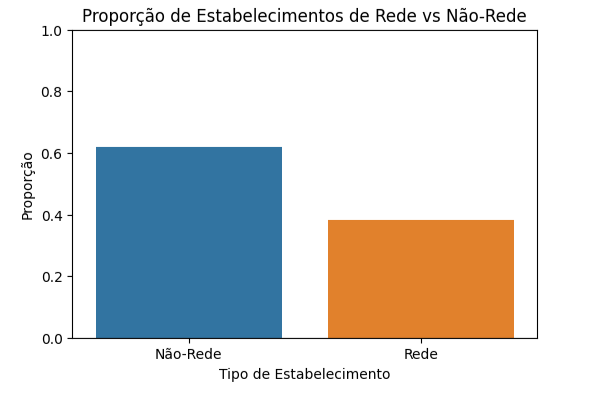

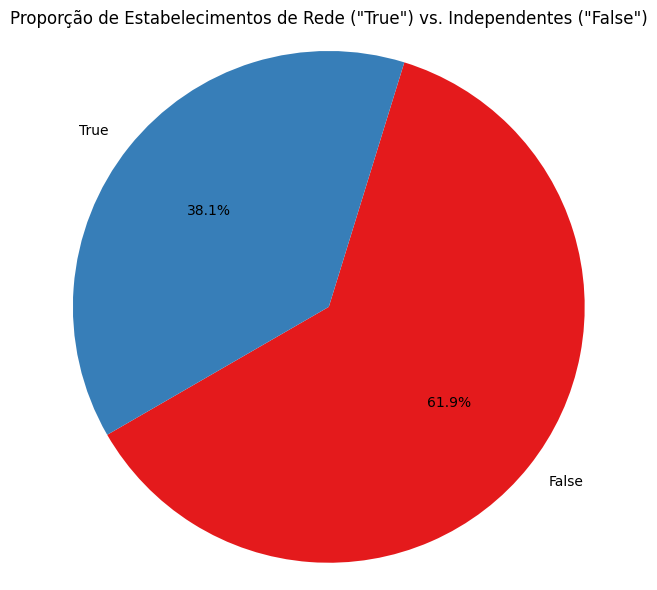

In [54]:
plt.figure(figsize=(6, 6))
plt.pie(
    chain_counts['proportion'],
    labels=chain_counts['chain'],
    autopct='%1.1f%%',
    colors=plt.get_cmap('Set1').colors,
    startangle=210
)

plt.title('Proporção de Estabelecimentos de Rede ("True") vs. Independentes ("False")')
plt.axis('equal')  # Mantém o gráfico em círculo
plt.tight_layout()
plt.show()

<span style="color: black; font-family: Arial; font-size: 20px;">
Aproximadamente 60% dos estabelecimentos não fazem parte de uma rede, enquanto 40% fazem parte de uma rede.

<span style="color: blue; font-family: Arial; font-size: 20px;">
Qual tipo de estabelecimento é típico para redes?

In [18]:
# Passo 1: Contar estabelecimentos por tipo e se são ou não parte de uma rede
chain_by_type = rest_data.groupby(['object_type', 'chain']).size().reset_index(name='count')
chain_by_type

,object_type,chain,count
0,Bakery,True,283
1,Bar,False,215
2,Bar,True,77
3,Cafe,False,169
4,Cafe,True,266
5,Fast Food,False,461
6,Fast Food,True,605
7,Pizza,False,166
8,Pizza,True,153
9,Restaurant,False,4961


In [19]:
# Passo 2: Calcular o total por tipo
chain_by_type['total'] = chain_by_type.groupby('object_type')['count'].transform('sum')
chain_by_type

,object_type,chain,count,total
0,Bakery,True,283,283
1,Bar,False,215,292
2,Bar,True,77,292
3,Cafe,False,169,435
4,Cafe,True,266,435
5,Fast Food,False,461,1066
6,Fast Food,True,605,1066
7,Pizza,False,166,319
8,Pizza,True,153,319
9,Restaurant,False,4961,7253


In [20]:
# Passo 3: Calcular a proporção relativa por tipo (dentro de cada object_type)
chain_by_type['proportion'] = chain_by_type['count'] / chain_by_type['total']
chain_by_type

,object_type,chain,count,total,proportion
0,Bakery,True,283,283,1.000000
1,Bar,False,215,292,0.736301
2,Bar,True,77,292,0.263699
3,Cafe,False,169,435,0.388506
4,Cafe,True,266,435,0.611494
5,Fast Food,False,461,1066,0.432458
6,Fast Food,True,605,1066,0.567542
7,Pizza,False,166,319,0.520376
8,Pizza,True,153,319,0.479624
9,Restaurant,False,4961,7253,0.683993


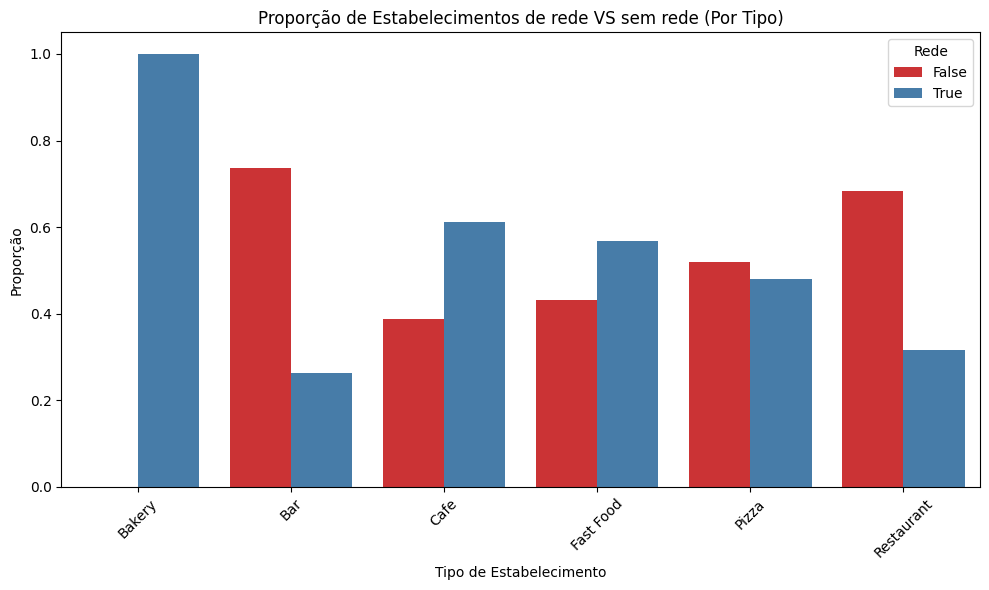

In [57]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=chain_by_type,
    x='object_type',
    y='proportion',
    hue='chain',
    palette='Set1'
)

plt.title('Proporção de Estabelecimentos de rede VS sem rede (Por Tipo)')
plt.xlabel('Tipo de Estabelecimento')
plt.ylabel('Proporção')
plt.xticks(rotation=45)
plt.legend(title='Rede')
plt.tight_layout()
plt.show()

<span style="color: black; font-family: Arial; font-size: 20px;">
O estabelecimento mais típico para redes é a Bakery, sendo que ela também não tem estabelecimentos sem rede.

<span style="color: blue; font-family: Arial; font-size: 20px;">
O que caracteriza redes: muitos estabelecimentos com um pequeno número de assentos ou poucos estabelecimentos com muitos assentos?

In [44]:
chain_true = rest_data[rest_data['chain'] == True]
chain_true

,id,object_name,address,chain,object_type,number,street_name
8,11794,ABC DONUTS,3027 N SAN FERNANDO RD UNIT 103,True,Fast Food,1,N SAN FERNANDO RD UNIT 103
10,11796,EL POLLO LOCO,5319 W SUNSET BLVD,True,Restaurant,38,W SUNSET BLVD
11,11797,POONG NYUN BAKERY,928 S WESTERN AVE STE 109,True,Bakery,17,S WESTERN AVE STE 109
12,11798,EMC RESTAURANT GROUP LLC,3500 W 6TH ST STE 101,True,Restaurant,133,W 6TH ST STE 101
14,11800,CUSCATLECA BAKERY,2501 W SUNSET BLVD #A,True,Bakery,26,W SUNSET BLVD #A
...,...,...,...,...,...,...,...
9629,21415,JUCUAPA BAKERY,2810 JAMES WOOD BLVD,True,Bakery,10,JAMES WOOD BLVD
9636,21422,CHIPOTLE #3094,6719 LA TIJERA BLVD A-B,True,Restaurant,47,LA TIJERA BLVD A-B
9639,21425,MCDONALD'S,1800 S WESTERN AVE,True,Fast Food,135,S WESTERN AVE
9648,21434,JUICY WINGZ,6741 HOLLYWOOD BLVD,True,Fast Food,15,HOLLYWOOD BLVD


In [54]:
chain_true['object_name'].value_counts().reset_index().head(15)

,index,object_name
0,THE COFFEE BEAN & TEA LEAF,47
1,SUBWAY,31
2,DOMINO'S PIZZA,15
3,KENTUCKY FRIED CHICKEN,14
4,WABA GRILL,14
5,TRIMANA,13
6,MCDONALD'S,13
7,YOGURTLAND,12
8,PAPA JOHN'S PIZZA,12
9,STARBUCKS,12


In [46]:
chain_true[chain_true['object_name'] == 'KENTUCKY FRIED CHICKEN'].sort_values(by='number', ascending=False)

,id,object_name,address,chain,object_type,number,street_name
727,12513,KENTUCKY FRIED CHICKEN,708 S BROADWAY,True,Fast Food,104,S BROADWAY
8034,19820,KENTUCKY FRIED CHICKEN,8515 S CENTRAL AVE,True,Fast Food,49,S CENTRAL AVE
7140,18926,KENTUCKY FRIED CHICKEN,1789 W JEFFERSON BLVD,True,Fast Food,48,W JEFFERSON BLVD
3957,15743,KENTUCKY FRIED CHICKEN,1400 GLENDALE BLVD,True,Fast Food,39,GLENDALE BLVD
5809,17595,KENTUCKY FRIED CHICKEN,1244 S LA BREA AVE,True,Fast Food,39,S LA BREA AVE
2943,14729,KENTUCKY FRIED CHICKEN,10501 W PICO BLVD,True,Fast Food,37,W PICO BLVD
7519,19305,KENTUCKY FRIED CHICKEN,1148 W MANCHESTER AVE,True,Fast Food,35,W MANCHESTER AVE
5287,17073,KENTUCKY FRIED CHICKEN,624 S LORENA ST,True,Fast Food,28,S LORENA ST
5451,17237,KENTUCKY FRIED CHICKEN,2801 N BROADWAY,True,Fast Food,27,N BROADWAY
311,12097,KENTUCKY FRIED CHICKEN,320 N SOTO ST,True,Fast Food,25,N SOTO ST


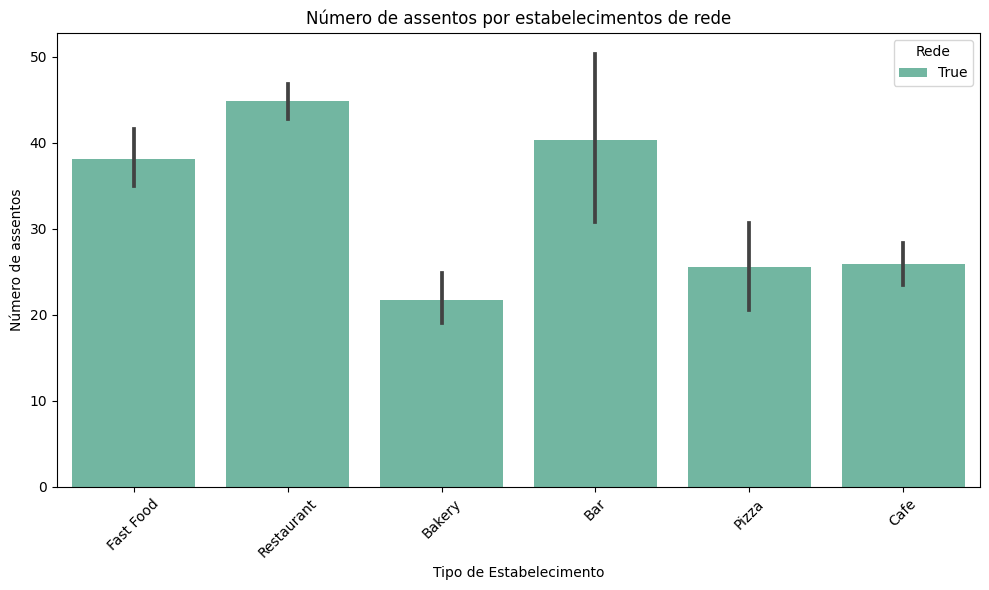

In [55]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=chain_true,
    x='object_type',
    y='number',
    hue='chain',
    palette='Set2'
)

plt.title('Número de assentos por estabelecimentos de rede')
plt.xlabel('Tipo de Estabelecimento')
plt.ylabel('Número de assentos')
plt.xticks(rotation=45)
plt.legend(title='Rede')
plt.tight_layout()
plt.show()
#rest_chain.number.hist()

<span style="color: black; font-family: Arial; font-size: 20px;">
Estabelecimentos de rede, apesar de estarem em número menor em relação aos estabelecimentos sem rede, possuem números de assentos maiores.

<span style="color: blue; font-family: Arial; font-size: 20px;">
Determine o número médio de assentos para cada tipo de restaurante. Em média, qual tipo de restaurante tem o maior número de assentos? Construa gráficos.

In [28]:
# Calculando a média de assentos por tipo de estabelecimento
mean_seats_by_type = rest_data.groupby('object_type')['number'].mean().sort_values(ascending=False).reset_index()
mean_seats_by_type

,object_type,number
0,Restaurant,48.042316
1,Bar,44.767123
2,Fast Food,31.837711
3,Pizza,28.459375
4,Cafe,25.000000
5,Bakery,21.773852


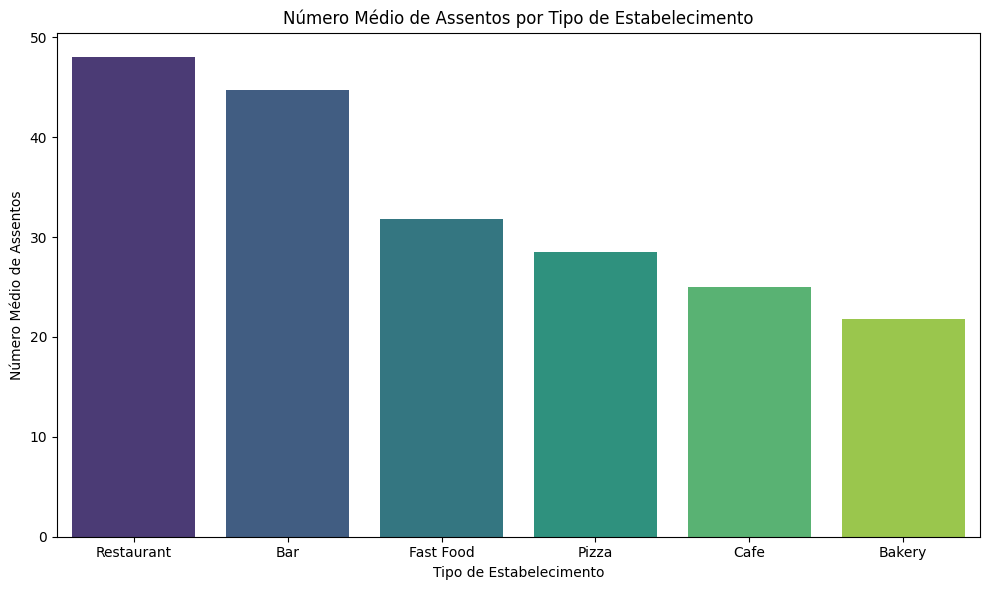

In [56]:
# Plotando gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(data=mean_seats_by_type, x='object_type', y='number', palette='viridis')
plt.title('Número Médio de Assentos por Tipo de Estabelecimento')
plt.xlabel('Tipo de Estabelecimento')
plt.ylabel('Número Médio de Assentos')
plt.tight_layout()
plt.show()

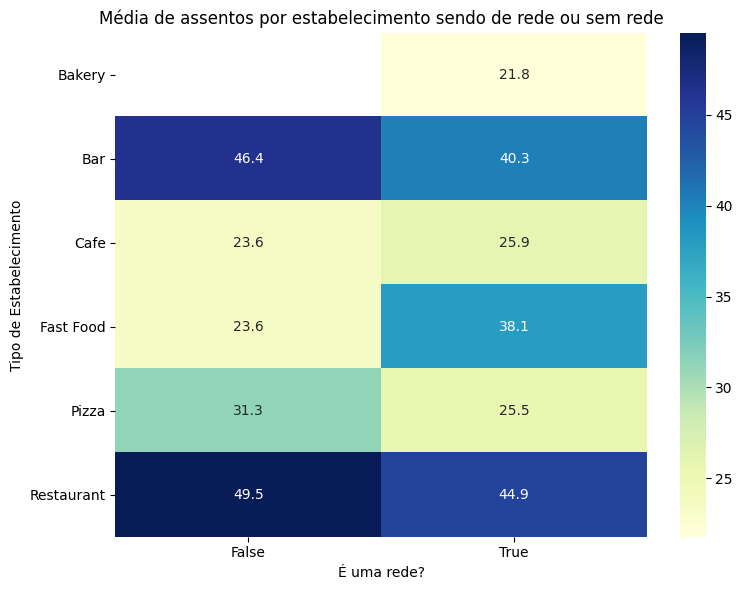

In [30]:
# Construindo um heatmap
heatmap_data = rest_data.pivot_table(
    values='number',
    index='object_type',
    columns='chain',
    aggfunc='mean'
)

# Plotar heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlGnBu')

plt.title('Média de assentos por estabelecimento sendo de rede ou sem rede')
plt.xlabel('É uma rede?')
plt.ylabel('Tipo de Estabelecimento')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-success">
<b>Comentário: </b> <a class="tocSkip"></a>
    
Os seus gráficos estão muito bons e respondem corretamente ao exercício! Caso queira analisar a distribuição dos assentos em mais detalhes, recomendo o uso de um histograma. Exemplo abaixo

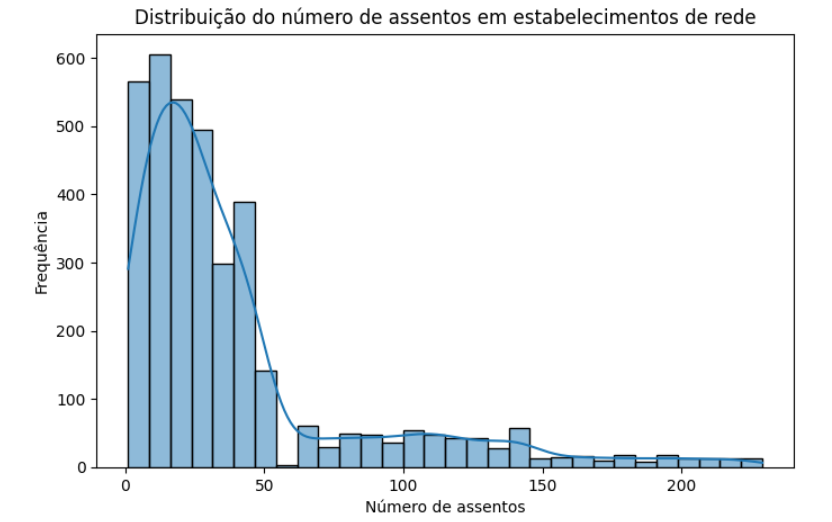

<span style="color: black; font-family: Arial; font-size: 20px;">
O tipo 'Restaurant' tem o maior número médio de assentos, tanto os que são de rede quanto os que não são.

<span style="color: blue; font-family: Arial; font-size: 20px;">
Coloque os dados dos nomes das ruas da coluna address em uma coluna separada.

In [31]:
rest_data['address'].unique()

array(['3708 N EAGLE ROCK BLVD', '100 WORLD WAY 120',
       '6801 HOLLYWOOD BLVD 253', ..., '6741 HOLLYWOOD BLVD',
       '548 S SPRING ST STE 100', '1300 S SAN PEDRO ST STE 111'],
      dtype=object)

In [32]:
rest_data['address'].nunique()

8512

In [33]:
# Removendo o número do começo de cada string
rest_data['street_name'] = rest_data["address"].str.replace(r"^\d+\s+", "", regex=True)
rest_data.head()

,id,object_name,address,chain,object_type,number,street_name
0,11786,HABITAT COFFEE SHOP,3708 N EAGLE ROCK BLVD,False,Cafe,26,N EAGLE ROCK BLVD
1,11787,REILLY'S,100 WORLD WAY 120,False,Restaurant,9,WORLD WAY 120
2,11788,STREET CHURROS,6801 HOLLYWOOD BLVD 253,False,Fast Food,20,HOLLYWOOD BLVD 253
3,11789,TRINITI ECHO PARK,1814 W SUNSET BLVD,False,Restaurant,22,W SUNSET BLVD
4,11790,POLLEN,2100 ECHO PARK AVE,False,Restaurant,20,ECHO PARK AVE


<div class="alert alert-block alert-success">
<b>Comentário: </b> <a class="tocSkip"></a>

Correto processamento do nome das ruas utilizando regex.

<span style="color: blue; font-family: Arial; font-size: 20px;">
Construa um gráfico de dez ruas com o maior número de restaurantes.

In [34]:
top_streets = rest_data["street_name"].value_counts().head(10)
top_streets

W SUNSET BLVD        296
W PICO BLVD          288
HOLLYWOOD BLVD       167
WILSHIRE BLVD        161
S VERMONT AVE        148
SANTA MONICA BLVD    146
W 3RD ST             145
BEVERLY BLVD         135
S FIGUEROA ST        134
MELROSE AVE          128
Name: street_name, dtype: int64

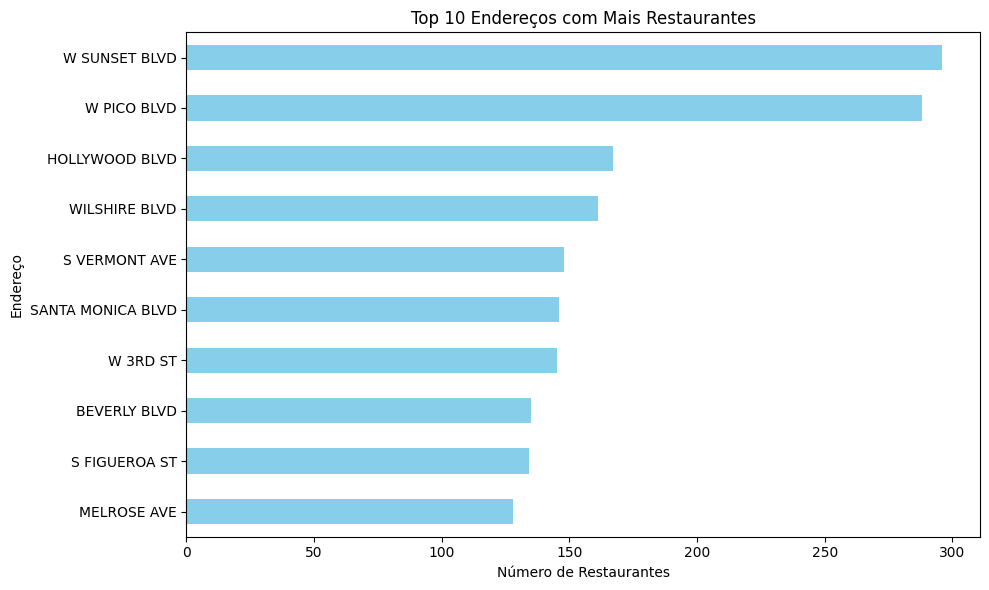

In [35]:
plt.figure(figsize=(10, 6))
top_streets.plot(kind='barh', color='skyblue')
plt.xlabel("Número de Restaurantes")
plt.ylabel("Endereço")
plt.title("Top 10 Endereços com Mais Restaurantes")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

<span style="color: black; font-family: Arial; font-size: 20px;">
As ruas ‘W Sunset Blvd’ e ‘W Pico Blvd’ são as que mais tem restaurantes.

<span style="color: blue; font-family: Arial; font-size: 20px;">
Encontre o número de ruas que têm apenas um restaurante.

In [36]:
street_counts = rest_data["street_name"].value_counts()
street_counts.head()

W SUNSET BLVD     296
W PICO BLVD       288
HOLLYWOOD BLVD    167
WILSHIRE BLVD     161
S VERMONT AVE     148
Name: street_name, dtype: int64

In [37]:
unique_street_count = (street_counts == 1).sum()
print("Número de ruas com apenas um restaurante:", unique_street_count)

Número de ruas com apenas um restaurante: 2450


<span style="color: black; font-family: Arial; font-size: 20px;">
Há 2450 ruas com apenas um restaurante.

<span style="color: blue; font-family: Arial; font-size: 20px;">
Para as ruas com muitos restaurantes, olhe para a distribuição de número de assentos. Quais tendências você consegue notar?

In [38]:
street_counts = rest_data["street_name"].value_counts().reset_index()
street_counts.columns = ["street_name", "restaurant_count"]
street_counts

,street_name,restaurant_count
0,W SUNSET BLVD,296
1,W PICO BLVD,288
2,HOLLYWOOD BLVD,167
3,WILSHIRE BLVD,161
4,S VERMONT AVE,148
...,...,...
3072,E FLORENCE AVE C,1
3073,W 7TH ST UNIT 150,1
3074,THE GROVE DRIVE K2,1
3075,S HILL ST STE M-105,1


In [39]:
streets_by_assents = rest_data.groupby('street_name')['number'].sum().reset_index()
streets_by_assents.columns = ["street_name", "total_seats"]
streets_by_assents.head()

,street_name,total_seats
0,1/2 3RD ST,19
1,1/2 7TH ST,49
2,1/2 BEVERLY BLVD,86
3,1/2 CITY TERRACE DR,1
4,1/2 COLORADO BLVD,25


In [40]:
merged_df = pd.merge(street_counts, streets_by_assents, on="street_name")
merged_df

,street_name,restaurant_count,total_seats
0,W SUNSET BLVD,296,15072
1,W PICO BLVD,288,11773
2,HOLLYWOOD BLVD,167,8973
3,WILSHIRE BLVD,161,10003
4,S VERMONT AVE,148,6790
...,...,...,...
3072,E FLORENCE AVE C,1,39
3073,W 7TH ST UNIT 150,1,1
3074,THE GROVE DRIVE K2,1,10
3075,S HILL ST STE M-105,1,19


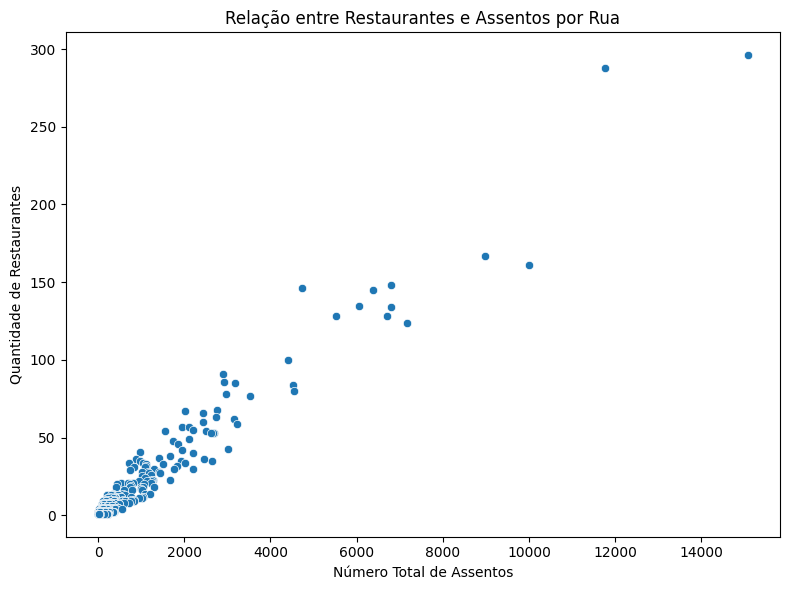

In [58]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x="total_seats", y="restaurant_count", data=merged_df)
plt.title("Relação entre Restaurantes e Assentos por Rua")
plt.xlabel("Número Total de Assentos")
plt.ylabel("Quantidade de Restaurantes")
plt.tight_layout()
plt.show()

<span style="color: black; font-family: Arial; font-size: 20px;">
Quanto mais restaurantes em uma rua, há mais quantidade de assentos de modo geral.

<div class="alert alert-block alert-warning">
<b>Comentário: </b> <a class="tocSkip"></a>
    
    
Aqui era recomendado analisar pelo nome da rua. Exemplo abaixo

```python
# Selecionar as 10 ruas com mais restaurantes
top_ruas = data['street'].value_counts().head(10).index

# Filtrar os dados para conter apenas restaurantes dessas ruas
data_top_ruas = data[data['street'].isin(top_ruas)]

# Criar um boxplot para visualizar a distribuição de assentos
plt.figure(figsize=(12,6))
sns.boxplot(x='street', y='number', data=data_top_ruas)

plt.title('Distribuição do número de assentos nas ruas com mais restaurantes')
plt.xlabel('Rua')
plt.ylabel('Número de assentos')
plt.xticks(rotation=45)
plt.show()

```
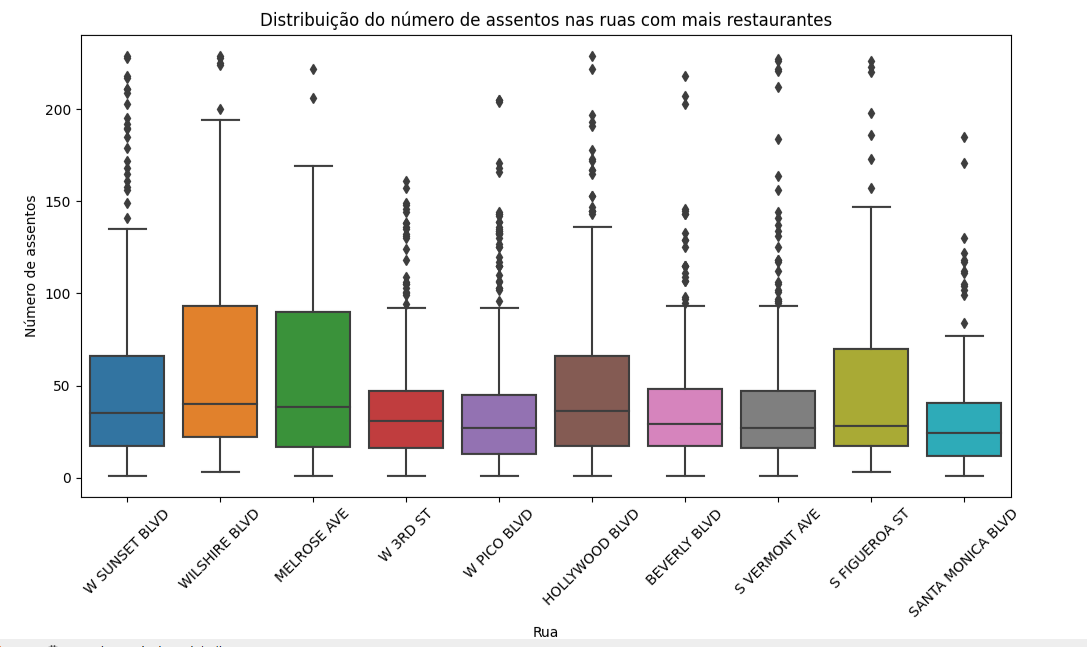

<span style="color: blue; font-family: Arial; font-size: 20px;">
Conclusões

<span style="color: black; font-family: Arial; font-size: 20px;">
O tipo mais apropriado de restaurante é o tipo 'Restaurant', que, como observada nas análises acima, foi a mais frequente no dataset.

O número mais apropriado de assentos é aproximadamente 33, que é a média da distribuição dos dados dos estabelecimentos.

In [52]:
print("Número médio de assentos:", mean_seats_by_type.mean())

Número médio de assentos: number    33.313396
dtype: float64


<span style="color: black; font-family: Arial; font-size: 20px;">
Os dados mostram boas condições para desenvolver uma rede, especialmente se for focada nos formatos de 'Restaurant' ou 'Fastfood'.

<div class="alert alert-block alert-success">
<b>Comentário: </b> <a class="tocSkip"></a>

Conclusão fundamentada com os dados da análise. Boa conclusão!

</div>

Presentation: <https://drive.google.com/file/d/1UBMHfP28BDFUln_MvadtICQk6qu0GzCz/view?usp=sharing>